In [ ]:
!pip install optuna

In [ ]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
import optuna
from sklearn.isotonic import IsotonicRegression

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE = Path("/content/drive/MyDrive/pruebas/pre")

EMB_DIR = BASE / "embeddings" / "embeddings_w2v"
SPEC_DIR = BASE / "spectral_feats"

TR_W2V = EMB_DIR / "train_embeddings_w2v.npz"
VA_W2V = EMB_DIR / "val_embeddings_w2v.npz"
TE_W2V = EMB_DIR / "test_embeddings_w2v.npz"

TR_SPEC = SPEC_DIR / "train_spectral.npz"
VA_SPEC = SPEC_DIR / "val_spectral.npz"
TE_SPEC = SPEC_DIR / "test_spectral.npz"

In [ ]:
def load_embed_npz(npz_path: Path):
    D = np.load(npz_path, allow_pickle=True)

    Xw = D["Xw"].astype(np.float32)
    zrms_log = D["zrms_log"].astype(np.float32).reshape(-1, 1)

    meta = pd.DataFrame({
        "path": D["path"].astype("U"),
        "clip_id": D["clip_id"].astype("U"),
        "start_samp": D["start_samp"].astype(np.int64),
        "end_samp": D["end_samp"].astype(np.int64),
        "valence": D["valence"].astype(np.float32),
        "arousal": D["arousal"].astype(np.float32),
        "dominance": D["dominance"].astype(np.float32),
        "win_rms": D["win_rms"].astype(np.float32),
        "zrms_log": D["zrms_log"].astype(np.float32),
    })
    return Xw, zrms_log, meta

In [ ]:
def load_spec_npz(npz_path: Path):
    D = np.load(npz_path, allow_pickle=True)

    Xspec = D["Xspec"].astype(np.float32)

    meta = pd.DataFrame({
        "path": D["path"].astype("U"),
        "clip_id": D["clip_id"].astype("U"),
        "start_samp": D["start_samp"].astype(np.int64),
        "end_samp": D["end_samp"].astype(np.int64),
    })
    return Xspec, meta

In [ ]:
def check_alignment(meta_a, meta_b, name="split"):
    ok = (
        (meta_a["path"].values == meta_b["path"].values).all() and
        (meta_a["clip_id"].values == meta_b["clip_id"].values).all() and
        (meta_a["start_samp"].values == meta_b["start_samp"].values).all() and
        (meta_a["end_samp"].values == meta_b["end_samp"].values).all()
    )
    print(name, "aligned:", ok)
    return ok

In [ ]:
def ccc2(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    yt = y_true.mean()
    yp = y_pred.mean()
    cov = np.mean((y_true - yt) * (y_pred - yp))
    vt = np.var(y_true)
    vp = np.var(y_pred)
    return (2 * cov) / (vt + vp + (yt - yp) ** 2 + 1e-8)

In [ ]:
def aggregate_median(df, preds, true_col="dominance"):
    df = df.copy()
    df["pred"] = preds

    out = []

    for cid, g in df.groupby("clip_id"):
        p = g["pred"].values.astype(np.float32)
        t = float(g[true_col].iloc[0])

        if np.isnan(p).any() or np.isnan(t):
            continue

        pred_clip = float(np.median(p))
        out.append((cid, pred_clip, t))

    return pd.DataFrame(out, columns=["clip_id", "pred", "true"])

In [ ]:
def report_all(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    bias = np.mean(y_pred - y_true)
    stdp = np.std(y_pred)
    corr = np.corrcoef(y_true, y_pred)[0, 1]

    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"Bias: {bias:.4f}")
    print(f"Std(pred): {stdp:.4f}")
    print(f"Corr(Pearson): {corr:.4f}")

In [ ]:
#baseline para seguir mejorandolo luego con optuna
def make_xgb():
    return XGBRegressor(
        objective="reg:squarederror",
        learning_rate=0.05,
        n_estimators=1000,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        tree_method="hist",
        device="cuda",
        eval_metric="rmse"
    )

In [ ]:
Xw_tr, zrms_tr, meta_tr = load_embed_npz(TR_W2V)
Xw_va, zrms_va, meta_va = load_embed_npz(VA_W2V)
Xw_te, zrms_te, meta_te = load_embed_npz(TE_W2V)

Xspec_tr, meta_spec_tr = load_spec_npz(TR_SPEC)
Xspec_va, meta_spec_va = load_spec_npz(VA_SPEC)
Xspec_te, meta_spec_te = load_spec_npz(TE_SPEC)

check_alignment(meta_tr, meta_spec_tr, "train")
check_alignment(meta_va, meta_spec_va, "val")
check_alignment(meta_te, meta_spec_te, "test")

train aligned: True
val aligned: True
test aligned: True


np.True_

In [ ]:
X_tr = np.concatenate([Xw_tr, zrms_tr, Xspec_tr], axis=1).astype(np.float32)
X_va = np.concatenate([Xw_va, zrms_va, Xspec_va], axis=1).astype(np.float32)
X_te = np.concatenate([Xw_te, zrms_te, Xspec_te], axis=1).astype(np.float32)

print("X_tr:", X_tr.shape)
print("X_va:", X_va.shape)
print("X_te:", X_te.shape)

X_tr: (38249, 2057)
X_va: (8459, 2057)
X_te: (9980, 2057)


In [ ]:
mu_X = X_tr.mean(axis=0, keepdims=True)
sd_X = X_tr.std(axis=0, keepdims=True) + 1e-8

X_tr_n = (X_tr - mu_X) / sd_X
X_va_n = (X_va - mu_X) / sd_X
X_te_n = (X_te - mu_X) / sd_X

In [ ]:
yD_tr = meta_tr["dominance"].to_numpy(np.float32)
yD_va = meta_va["dominance"].to_numpy(np.float32)
yD_te = meta_te["dominance"].to_numpy(np.float32)

yD_mean = yD_tr.mean()
yD_std  = yD_tr.std() + 1e-8

yD_tr_n = (yD_tr - yD_mean) / yD_std
yD_va_n = (yD_va - yD_mean) / yD_std

In [ ]:
params_base = {'learning_rate': 0.04059318862232281, 'max_leaves': 41, 'min_child_weight': 7.722016373149735, 'subsample': 0.6751144157601281, 'colsample_bytree': 0.7844973809329394, 'colsample_bynode': 0.6465387135151781, 'gamma': 0.21211973708943715, 'reg_alpha': 8.387101901360296, 'reg_lambda': 61.439124226254755, 'max_bin': 257}
iter_base = 1036

### guardo log rms

In [ ]:
eps = 1e-6
log_mu  = np.log1p(meta_tr["win_rms"] + eps).mean()
log_std = np.log1p(meta_tr["win_rms"] + eps).std(ddof=1) + 1e-9

In [ ]:
log_mu

np.float32(0.08981785)

In [ ]:
log_std

0.08029861848218536

In [ ]:
import joblib

In [ ]:
joblib.dump({
    "log_mu": float(log_mu),
    "log_std": float(log_std),
}, "rms_norm.pkl")

['rms_norm.pkl']

# Modelo base

se usa hiperparametros que maximizaron arousal para tener un buen punto de partida

In [ ]:
model_D_base = XGBRegressor(
    **params_base,
    objective="reg:squarederror",
    tree_method="hist",
    device="cuda",
    n_estimators=iter_base,
    max_depth=0,
    grow_policy="lossguide",
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1,
)

In [ ]:
model_D_base.fit(
    X_tr_n, yD_tr_n,
    eval_set=[(X_va_n, yD_va_n)],
    verbose=100
)

[0]	validation_0-rmse:1.06895
[100]	validation_0-rmse:0.85259
[200]	validation_0-rmse:0.82493
[300]	validation_0-rmse:0.81026
[400]	validation_0-rmse:0.80159
[500]	validation_0-rmse:0.79580
[600]	validation_0-rmse:0.79204
[700]	validation_0-rmse:0.78866
[800]	validation_0-rmse:0.78660
[900]	validation_0-rmse:0.78427
[1000]	validation_0-rmse:0.78238
[1035]	validation_0-rmse:0.78231


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=0.6465387135151781,
             colsample_bytree=0.7844973809329394, device='cuda',
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric='rmse', feature_types=None, feature_weights=None,
             gamma=0.21211973708943715, grow_policy='lossguide',
             importance_type=None, interaction_constraints=None,
             learning_rate=0.04059318862232281, max_bin=257,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=0, max_leaves=41,
             min_child_weight=7.722016373149735, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1036,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
pred_va_D = model_D_base.predict(X_va_n)
pred_te_D = model_D_base.predict(X_te_n)

pred_va_D_denorm = pred_va_D * yD_std + yD_mean
pred_te_D_denorm = pred_te_D * yD_std + yD_mean

df_clip_va_D = aggregate_median(meta_va, pred_va_D_denorm, true_col="dominance")
df_clip_te_D = aggregate_median(meta_te, pred_te_D_denorm, true_col="dominance")

ccc_va_D = ccc2(df_clip_va_D["true"].values, df_clip_va_D["pred"].values)
ccc_te_D = ccc2(df_clip_te_D["true"].values, df_clip_te_D["pred"].values)

print("CCC VAL baseline:", ccc_va_D)
print("CCC TEST baseline:", ccc_te_D)

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [02:56:54] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


CCC VAL baseline: 0.6738435630685717
CCC TEST baseline: 0.6245106373267943


#Optuna para optimizar

In [ ]:
def objective_dominance(trial):
    params = {
      "objective": "reg:squarederror",
      "tree_method": "hist",
      "device": "cuda",
      "eval_metric": "rmse",
      "random_state": 42,
      "n_jobs": -1,

      "n_estimators": 2500,

      "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.12, log=True),
      "max_leaves": trial.suggest_int("max_leaves", 32, 56),
      "min_child_weight": trial.suggest_float("min_child_weight", 5.0, 12.0),

      "subsample": trial.suggest_float("subsample", 0.62, 0.78),
      "colsample_bytree": trial.suggest_float("colsample_bytree", 0.68, 0.86),
      "colsample_bynode": trial.suggest_float("colsample_bynode", 0.55, 0.75),

      "gamma": trial.suggest_float("gamma", 0.05, 0.30),
      "reg_alpha": trial.suggest_float("reg_alpha", 6.0, 10.0),
      "reg_lambda": trial.suggest_float("reg_lambda", 40.0, 80.0),
      "max_bin": trial.suggest_int("max_bin", 200, 300),

      "grow_policy": "lossguide",
      "max_depth": 0,
      "early_stopping_rounds": 150,
  }

    model = XGBRegressor(**params)

    model.fit(
        X_tr_n,
        yD_tr_n,
        eval_set=[(X_va_n, yD_va_n)],
        verbose=False,
    )

    pred_va = model.predict(X_va_n)
    pred_va_denorm = pred_va * yD_std + yD_mean

    df_clip_va = aggregate_median(meta_va, pred_va_denorm, true_col="dominance")

    ccc_clip = ccc2(df_clip_va["true"].values, df_clip_va["pred"].values)
    rmse_val = np.sqrt(np.mean((yD_va - pred_va_denorm) ** 2))

    trial.set_user_attr("ccc_clip", float(ccc_clip))
    trial.set_user_attr("rmse_window", float(rmse_val))
    trial.set_user_attr("best_iteration", int(getattr(model, "best_iteration", -1)))

    print(f"Trial {trial.number} | CCC: {ccc_clip:.4f} | RMSE: {rmse_val:.4f}")
    return 1.0 - ccc_clip

In [ ]:
def print_callback(study, trial):
    print(f"Best CCC so far: {1 - study.best_value:.4f}")

In [ ]:
study = optuna.create_study(direction="minimize")

study.enqueue_trial({
    "learning_rate": 0.04059318862232281,
    "subsample": 0.6751144157601281,
    "colsample_bytree": 0.7844973809329394,
    "reg_lambda": 61.439124226254755,
    'max_leaves': 41,
    'min_child_weight': 7.722016373149735,
    'colsample_bynode': 0.6465387135151781,
    'gamma': 0.21211973708943715,
    'reg_alpha': 8.387101901360296,
    'max_bin': 257
})

[I 2026-04-14 03:12:07,300] A new study created in memory with name: no-name-af7e3f13-4d98-430e-aa16-dece674bc0fc


In [ ]:
study.optimize(objective_dominance, n_trials=30, callbacks=[print_callback])

print("Best params:", study.best_params)
print("Best CCC clip-level:", 1 - study.best_value)
print("Best attrs:", study.best_trial.user_attrs)

[I 2026-04-14 03:14:41,466] Trial 0 finished with value: 0.3212005402758299 and parameters: {'learning_rate': 0.04059318862232281, 'max_leaves': 41, 'min_child_weight': 7.722016373149735, 'subsample': 0.6751144157601281, 'colsample_bytree': 0.7844973809329394, 'colsample_bynode': 0.6465387135151781, 'gamma': 0.21211973708943715, 'reg_alpha': 8.387101901360296, 'reg_lambda': 61.439124226254755, 'max_bin': 257}. Best is trial 0 with value: 0.3212005402758299.


Trial 0 | CCC: 0.6788 | RMSE: 0.6996
Best CCC so far: 0.6788


[I 2026-04-14 03:15:52,151] Trial 1 finished with value: 0.3212858481237756 and parameters: {'learning_rate': 0.08719932304302015, 'max_leaves': 42, 'min_child_weight': 7.680652611871811, 'subsample': 0.7490488649810583, 'colsample_bytree': 0.733044507066885, 'colsample_bynode': 0.5656127234155025, 'gamma': 0.17983255441536133, 'reg_alpha': 9.697307761429542, 'reg_lambda': 42.33477353203729, 'max_bin': 258}. Best is trial 0 with value: 0.3212005402758299.


Trial 1 | CCC: 0.6787 | RMSE: 0.6984
Best CCC so far: 0.6788


[I 2026-04-14 03:16:59,030] Trial 2 finished with value: 0.32421969875033707 and parameters: {'learning_rate': 0.09081694965696221, 'max_leaves': 44, 'min_child_weight': 11.08984331704671, 'subsample': 0.6860520774443536, 'colsample_bytree': 0.7594455119085431, 'colsample_bynode': 0.5834856641558042, 'gamma': 0.16425821255003364, 'reg_alpha': 6.9694890258320985, 'reg_lambda': 57.61723893363174, 'max_bin': 210}. Best is trial 0 with value: 0.3212005402758299.


...

Trial 27 | CCC: 0.6783 | RMSE: 0.6980
Best CCC so far: 0.6843


[I 2026-04-14 04:13:50,867] Trial 28 finished with value: 0.31980058568685565 and parameters: {'learning_rate': 0.033505114547607344, 'max_leaves': 34, 'min_child_weight': 9.169872108260524, 'subsample': 0.7663417247467574, 'colsample_bytree': 0.7443719912181919, 'colsample_bynode': 0.6159116539538768, 'gamma': 0.1992845945193234, 'reg_alpha': 8.838459164186755, 'reg_lambda': 48.232494594665276, 'max_bin': 252}. Best is trial 24 with value: 0.31574105585855994.


Trial 28 | CCC: 0.6802 | RMSE: 0.6964
Best CCC so far: 0.6843


[I 2026-04-14 04:15:58,097] Trial 29 finished with value: 0.318551698460409 and parameters: {'learning_rate': 0.03926333830997476, 'max_leaves': 41, 'min_child_weight': 8.303623797404633, 'subsample': 0.7423462124164175, 'colsample_bytree': 0.7896300832411642, 'colsample_bynode': 0.6397443038789611, 'gamma': 0.2196049272978498, 'reg_alpha': 9.668462754068145, 'reg_lambda': 62.574055607851136, 'max_bin': 200}. Best is trial 24 with value: 0.31574105585855994.


Trial 29 | CCC: 0.6814 | RMSE: 0.6987
Best CCC so far: 0.6843
Best params: {'learning_rate': 0.047520348331533534, 'max_leaves': 34, 'min_child_weight': 11.916289513869577, 'subsample': 0.7617937787154916, 'colsample_bytree': 0.7433890694269352, 'colsample_bynode': 0.6250873564523768, 'gamma': 0.19497057964373388, 'reg_alpha': 9.621903209995404, 'reg_lambda': 55.79067093389257, 'max_bin': 230}
Best CCC clip-level: 0.6842589441414401
Best attrs: {'ccc_clip': 0.6842589441414401, 'rmse_window': 0.6954061985015869, 'best_iteration': 2465}


## Modelo final (más óptimo)

In [ ]:
best_params = study.best_params
best_iter = study.best_trial.user_attrs["best_iteration"]

model_D_final = XGBRegressor(
    **best_params,
    objective="reg:squarederror",
    tree_method="hist",
    device="cuda",
    n_estimators=best_iter,
    max_depth=0,
    grow_policy="lossguide",
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1,
)

model_D_final.fit(X_tr_n, yD_tr_n, verbose=False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=0.6250873564523768,
             colsample_bytree=0.7433890694269352, device='cuda',
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric='rmse', feature_types=None, feature_weights=None,
             gamma=0.19497057964373388, grow_policy='lossguide',
             importance_type=None, interaction_constraints=None,
             learning_rate=0.047520348331533534, max_bin=230,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=0, max_leaves=34,
             min_child_weight=11.916289513869577, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=2465,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
pred_va = model_D_final.predict(X_va_n)
pred_te = model_D_final.predict(X_te_n)

pred_va_denorm = pred_va * yD_std + yD_mean
pred_te_denorm = pred_te * yD_std + yD_mean

df_clip_va = aggregate_median(meta_va, pred_va_denorm, true_col="dominance")
df_clip_te = aggregate_median(meta_te, pred_te_denorm, true_col="dominance")

ccc_va = ccc2(df_clip_va["true"].values, df_clip_va["pred"].values)
ccc_te = ccc2(df_clip_te["true"].values, df_clip_te["pred"].values)

print("CCC VAL final:", ccc_va)
print("CCC TEST final:", ccc_te)

CCC VAL final: 0.6842536816524145
CCC TEST final: 0.6425994590983851


Resultados sin calibracion

In [ ]:
print("VALIDATION")
report_all(df_clip_va["true"].values, df_clip_va["pred"].values)

print("\nTEST")
report_all(df_clip_te["true"].values, df_clip_te["pred"].values)

VALIDATION
MAE: 0.5226
RMSE: 0.6508
Bias: -0.1358
Std(pred): 0.6601
Corr(Pearson): 0.7381

TEST
MAE: 0.5744
RMSE: 0.7115
Bias: -0.1588
Std(pred): 0.5924
Corr(Pearson): 0.7532


## Calibración (mejora de resultados)

In [ ]:
iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(df_clip_va["pred"].values, df_clip_va["true"].values)

pred_va_iso = iso.predict(df_clip_va["pred"].values)
pred_te_iso = iso.predict(df_clip_te["pred"].values)

print("CCC VAL raw :", ccc2(df_clip_va["true"], df_clip_va["pred"]))
print("CCC TEST raw:", ccc2(df_clip_te["true"], df_clip_te["pred"]))

print("CCC VAL iso :", ccc2(df_clip_va["true"], pred_va_iso))
print("CCC TEST iso:", ccc2(df_clip_te["true"], pred_te_iso))

CCC VAL raw : 0.6842536816524145
CCC TEST raw: 0.6425994590983851
CCC VAL iso : 0.7231279084656141
CCC TEST iso: 0.6947009533659342


Resultados con calibracion

In [ ]:
print("VALIDATION")
report_all(df_clip_va["true"].values, pred_va_iso)

print("\nTEST")
report_all(df_clip_te["true"].values, pred_te_iso)

VALIDATION
MAE: 0.4996
RMSE: 0.6204
Bias: 0.0000
Std(pred): 0.7089
Corr(Pearson): 0.7525

TEST
MAE: 0.5464
RMSE: 0.6757
Bias: -0.0061
Std(pred): 0.6747
Corr(Pearson): 0.7549


In [ ]:
y_true_te = df_clip_te["true"].values
y_pred_te = pred_te_iso

In [ ]:
y_true_va = df_clip_va["true"].values
y_pred_va = pred_va_iso

In [ ]:
# MAE por bins de arousal
bins = [1, 2, 3, 4, 5]
print("MAE por bin (TEST):")
for i in range(len(bins) - 1):
    mask = (y_true_te >= bins[i]) & (y_true_te < bins[i+1])
    if np.sum(mask) > 0:
        mae = np.mean(np.abs(y_true_te[mask] - y_pred_te[mask]))
        print(f"  {bins[i]}-{bins[i+1]} -> MAE: {mae:.3f}  (n={np.sum(mask)})")

MAE por bin (TEST):
  1-2 -> MAE: 0.875  (n=58)
  2-3 -> MAE: 0.543  (n=1118)
  3-4 -> MAE: 0.470  (n=825)
  4-5 -> MAE: 0.294  (n=640)


In [ ]:
val_ccc_va_iso = ccc2(df_clip_va["true"], pred_va_iso)

# Visualizaciones

Las siguientes visualizaciones muestran comportamiento entre real/pred sin calibracion

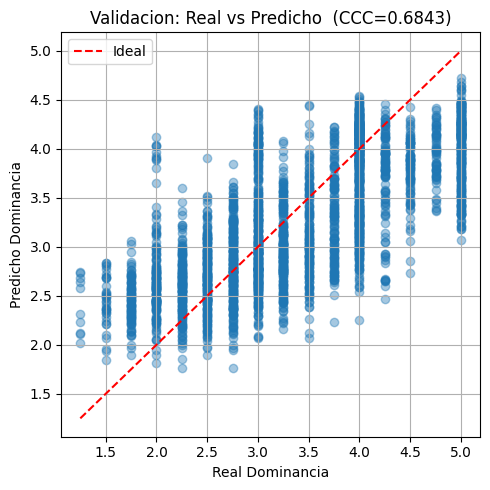

In [ ]:
min_v = min(df_clip_va['true'].min(), df_clip_va['pred'].min())
max_v = max(df_clip_va['true'].max(), df_clip_va['pred'].max())

plt.figure(figsize=(5, 5))
plt.scatter(df_clip_va['true'], df_clip_va['pred'], alpha=0.4)
plt.plot([min_v, max_v], [min_v, max_v], 'r--', label="Ideal")
plt.xlabel("Real Dominancia")
plt.ylabel("Predicho Dominancia")
plt.title(f"Validacion: Real vs Predicho  (CCC={ccc_va:.4f})")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

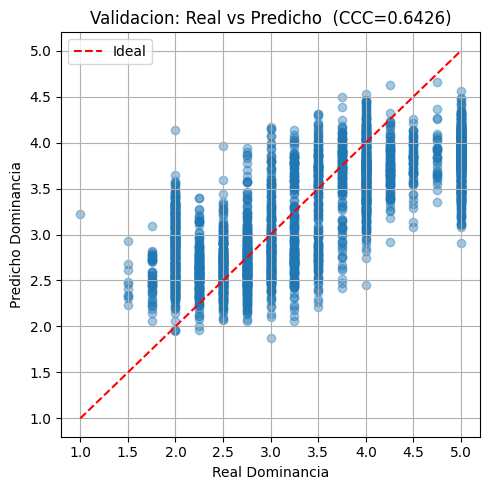

In [ ]:
min_v = min(df_clip_te['true'].min(), df_clip_te['pred'].min())
max_v = max(df_clip_te['true'].max(), df_clip_te['pred'].max())

plt.figure(figsize=(5, 5))
plt.scatter(df_clip_te['true'], df_clip_te['pred'], alpha=0.4)
plt.plot([min_v, max_v], [min_v, max_v], 'r--', label="Ideal")
plt.xlabel("Real Dominancia")
plt.ylabel("Predicho Dominancia")
plt.title(f"Validacion: Real vs Predicho  (CCC={ccc_te:.4f})")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

Las siguientes visualizaciones muestran comportamiento entre real/pred con calibracion

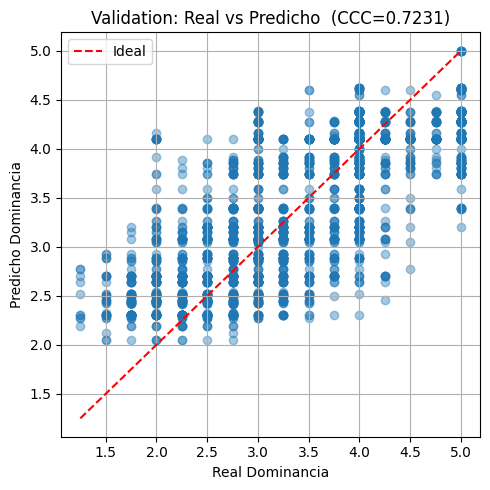

In [ ]:
import matplotlib.pyplot as plt

# --- Scatter VAL con línea ideal ---
min_v = min(y_true_va.min(), y_pred_va.min())
max_v = max(y_true_va.max(), y_pred_va.max())

plt.figure(figsize=(5, 5))
plt.scatter(y_true_va, y_pred_va, alpha=0.4)
plt.plot([min_v, max_v], [min_v, max_v], 'r--', label="Ideal")
plt.xlabel("Real Dominancia")
plt.ylabel("Predicho Dominancia")
plt.title(f"Validation: Real vs Predicho  (CCC={val_ccc_va_iso:.4f})")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
val_ccc_te_iso = ccc2(df_clip_te["true"], pred_te_iso)

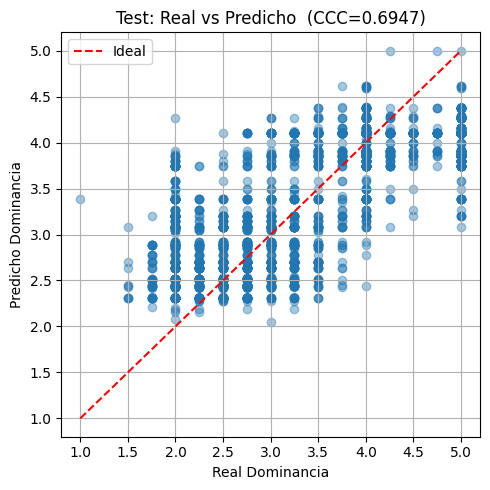

In [ ]:
# --- Scatter TEST con línea ideal ---
min_v = min(y_true_te.min(), y_pred_te.min())
max_v = max(y_true_te.max(), y_pred_te.max())

plt.figure(figsize=(5, 5))
plt.scatter(y_true_te, y_pred_te, alpha=0.4)
plt.plot([min_v, max_v], [min_v, max_v], 'r--', label="Ideal")
plt.xlabel("Real Dominancia")
plt.ylabel("Predicho Dominancia")
plt.title(f"Test: Real vs Predicho  (CCC={val_ccc_te_iso:.4f})")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

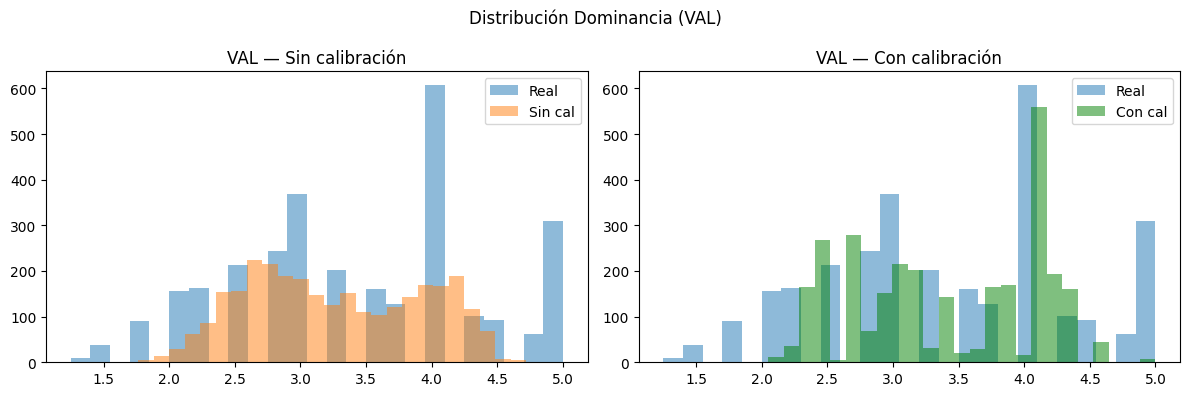

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_clip_va["true"], bins=25, alpha=0.5, label="Real")
axes[0].hist(df_clip_va["pred"].values, bins=25, alpha=0.5, label="Sin cal")
axes[0].set_title("VAL — Sin calibración")
axes[0].legend()

axes[1].hist(y_true_va, bins=25, alpha=0.5, label="Real")
axes[1].hist(y_pred_va, bins=25, alpha=0.5, label="Con cal", color='green')
axes[1].set_title("VAL — Con calibración")
axes[1].legend()

plt.suptitle("Distribución Dominancia (VAL)")
plt.tight_layout()
plt.show()

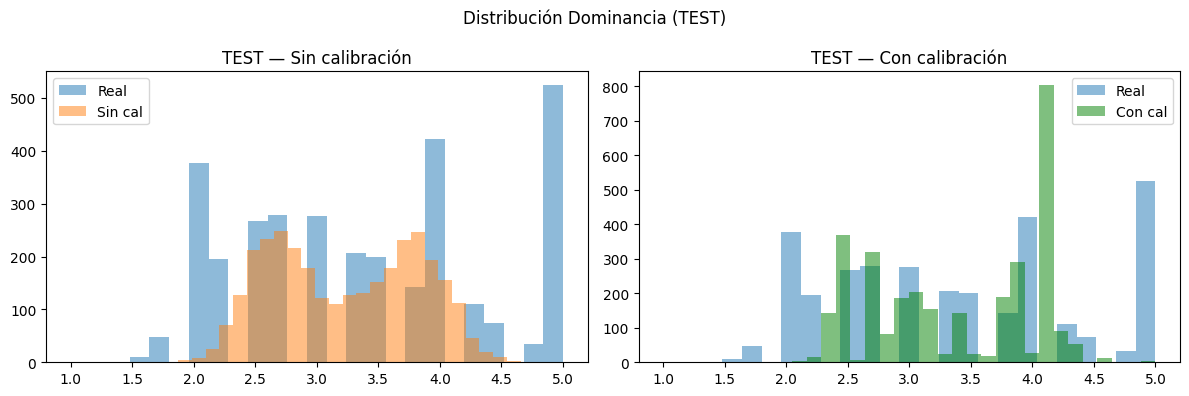

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_clip_te["true"], bins=25, alpha=0.5, label="Real")
axes[0].hist(df_clip_te["pred"].values, bins=25, alpha=0.5, label="Sin cal")
axes[0].set_title("TEST — Sin calibración")
axes[0].legend()

axes[1].hist(y_true_te, bins=25, alpha=0.5, label="Real")
axes[1].hist(y_pred_te, bins=25, alpha=0.5, label="Con cal", color='green')
axes[1].set_title("TEST — Con calibración")
axes[1].legend()

plt.suptitle("Distribución Dominancia (TEST)")
plt.tight_layout()
plt.show()

# Guarda modelo

In [ ]:
import joblib

In [ ]:
BASE = Path('/content/drive/MyDrive/pruebas/mod/base/dom')

In [ ]:
joblib.dump(model_D_final, BASE/"model_D_final.joblib")

['/content/drive/MyDrive/pruebas/mod/base/dom/model_D_final.joblib']

In [ ]:
joblib.dump(iso, BASE / "iso_dominance.joblib")

['/content/drive/MyDrive/pruebas/mod/base/dom/iso_dominance.joblib']

In [ ]:
joblib.dump({
    "mu_X": mu_X,
    "sd_X": sd_X,
    "y_mean": yD_mean,
    "y_std": yD_std,
}, BASE / "norm_dominance.pkl")

with open(BASE / "params_dominance.json", "w") as f:
    json.dump({
        **best_params,
        "n_estimators": int(best_iter)
    }, f, indent=2)


results_dominance = {
    "ccc_val_raw": float(ccc2(df_clip_va["true"], df_clip_va["pred"])),
    "ccc_test_raw": float(ccc2(df_clip_te["true"], df_clip_te["pred"])),
    "ccc_val_iso": float(ccc2(df_clip_va["true"], pred_va_iso)),
    "ccc_test_iso": float(ccc2(df_clip_te["true"], pred_te_iso)),
}

In [ ]:
with open(BASE / "results_dominance.json", "w") as f:
    json.dump(results_dominance, f, indent=2)

# predicciones por clip
np.savez_compressed(
    BASE / "preds_dominance.npz",
    true_va=df_clip_va["true"].values.astype(np.float32),
    pred_va_raw=df_clip_va["pred"].values.astype(np.float32),
    pred_va_iso=np.asarray(pred_va_iso, dtype=np.float32),
    true_te=df_clip_te["true"].values.astype(np.float32),
    pred_te_raw=df_clip_te["pred"].values.astype(np.float32),
    pred_te_iso=np.asarray(pred_te_iso, dtype=np.float32),
)

print("Dominance guardado")

Dominance guardado


In [ ]:
import os

files = [
    "/content/drive/MyDrive/pruebas/mod/base/dom/model_D_final.joblib",
    "/content/drive/MyDrive/pruebas/mod/base/dom/iso_dominance.joblib",
    "/content/drive/MyDrive/pruebas/mod/base/dom/norm_dominance.pkl",
    "/content/drive/MyDrive/pruebas/mod/base/dom/params_dominance.json",
    "/content/drive/MyDrive/pruebas/mod/base/dom/results_dominance.json",
    "/content/drive/MyDrive/pruebas/mod/base/dom/preds_dominance.npz",
]

for f in files:
    print(os.path.exists(f), f)

True /content/drive/MyDrive/pruebas/mod/base/dom/model_D_final.joblib
True /content/drive/MyDrive/pruebas/mod/base/dom/iso_dominance.joblib
True /content/drive/MyDrive/pruebas/mod/base/dom/norm_dominance.pkl
True /content/drive/MyDrive/pruebas/mod/base/dom/params_dominance.json
True /content/drive/MyDrive/pruebas/mod/base/dom/results_dominance.json
True /content/drive/MyDrive/pruebas/mod/base/dom/preds_dominance.npz


median en dominance porque es más robusto a ruido

trimmed mean en valence porque captura mejor variación emocional

# agregacion de pesos (no lo mejora)

In [ ]:
def make_bin_weights_dominance(y):
    bins = np.linspace(y.min(), y.max(), 6)  # 5 bins adaptativos
    cats = pd.cut(y, bins=bins, include_lowest=True)

    freq = cats.value_counts().sort_index()
    inv = 1.0 / freq
    inv = inv / inv.mean()

    return np.array([inv[c] for c in cats], dtype=np.float32)

In [ ]:
sample_w = make_bin_weights_dominance(yD_tr)

model_D_w = XGBRegressor(
    **best_params,
    n_estimators=best_iter,
    objective="reg:squarederror",
    tree_method="hist",
    device="cuda",
    max_depth=0,
    grow_policy="lossguide",
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1,
)

model_D_w.fit(X_tr_n, yD_tr_n, sample_weight=sample_w)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=0.6250873564523768,
             colsample_bytree=0.7433890694269352, device='cuda',
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric='rmse', feature_types=None, feature_weights=None,
             gamma=0.19497057964373388, grow_policy='lossguide',
             importance_type=None, interaction_constraints=None,
             learning_rate=0.047520348331533534, max_bin=230,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=0, max_leaves=34,
             min_child_weight=11.916289513869577, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=2465,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
pred_va_w = model_D_w.predict(X_va_n)
pred_te_w = model_D_w.predict(X_te_n)

pred_va_w_denorm = pred_va_w * yD_std + yD_mean
pred_te_w_denorm = pred_te_w * yD_std + yD_mean

In [ ]:
df_clip_va_w = aggregate_median(meta_va, pred_va_w_denorm, true_col="dominance")
df_clip_te_w = aggregate_median(meta_te, pred_te_w_denorm, true_col="dominance")

In [ ]:
ccc_va_w = ccc2(df_clip_va_w["true"].values, df_clip_va_w["pred"].values)
ccc_te_w = ccc2(df_clip_te_w["true"].values, df_clip_te_w["pred"].values)

In [ ]:
iso_w = IsotonicRegression(out_of_bounds="clip")
iso_w.fit(df_clip_va_w["pred"].values, df_clip_va_w["true"].values)

pred_va_w_iso = iso_w.predict(df_clip_va_w["pred"].values)
pred_te_w_iso = iso_w.predict(df_clip_te_w["pred"].values)

In [ ]:
ccc_va_w_iso = ccc2(df_clip_va_w["true"], pred_va_w_iso)
ccc_te_w_iso = ccc2(df_clip_te_w["true"], pred_te_w_iso)

In [ ]:
print("RAW sin weights:", ccc_te)
print("RAW con weights:", ccc_te_w)

print("ISO sin weights:", ccc2(df_clip_te["true"], pred_te_iso))
print("ISO con weights:", ccc_te_w_iso)

RAW sin weights: 0.6425994590983851
RAW con weights: 0.6399164004282691
ISO sin weights: 0.6947009533659342
ISO con weights: 0.6600488900373198
